In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('D:\code\8020group\data\hi1_20170701_20200609.csv')
print(df.describe())

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\11614\AppData\Local\Temp\ipykernel_22556\4229382625.py:5: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv('D:\code\8020group\data\hi1_20170701_20200609.csv')


               date           time       hi1_open       hi1_high  \
count  5.821000e+05  582100.000000  582100.000000  582100.000000   
mean   2.018532e+07  153290.285003   27820.945932   27828.130783   
std    8.961189e+03   58402.336181    1914.098127    1913.179377   
min    2.017070e+07       0.000000   20981.000000   21049.000000   
25%    2.018041e+07  113300.000000   26506.000000   26514.000000   
50%    2.019010e+07  155100.000000   27756.000000   27762.000000   
75%    2.019091e+07  201500.000000   28919.000000   28924.000000   
max    2.020061e+07  235900.000000   33453.000000   33516.000000   

             hi1_low      hi1_close     hi1_volume  
count  582100.000000  582100.000000  582100.000000  
mean    27814.608885   27821.134869     221.235398  
std      1914.751378    1914.058534     301.240005  
min     20965.000000   20981.000000       0.000000  
25%     26500.000000   26506.000000      32.000000  
50%     27751.000000   27756.000000     106.000000  
75%     28914.00

In [2]:
print(df.head(10))


       date   time  hi1_open  hi1_high  hi1_low  hi1_close  hi1_volume
0  20170703  91400   25524.0   25524.0  25524.0    25524.0       639.0
1  20170703  91500   25530.0   25557.0  25506.0    25547.0       941.0
2  20170703  91600   25549.0   25564.0  25547.0    25560.0       371.0
3  20170703  91700   25558.0   25568.0  25549.0    25568.0       383.0
4  20170703  91800   25568.0   25574.0  25558.0    25562.0       288.0
5  20170703  91900   25564.0   25569.0  25551.0    25561.0       223.0
6  20170703  92000   25562.0   25566.0  25555.0    25565.0       195.0
7  20170703  92100   25564.0   25565.0  25555.0    25561.0       113.0
8  20170703  92200   25562.0   25574.0  25559.0    25571.0       190.0
9  20170703  92300   25572.0   25576.0  25567.0    25572.0       138.0


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
C:\Users\11614\AppData\Local\Temp\ipykernel_36648\592583951.py:6: SyntaxWarning: invalid escape sequence '\c'
  file_path = 'D:\code\8020group\data\hi1_20170701_20200609.csv'


原始数据形状: (582100, 7)

前5行预览:
        date   time  hi1_open  hi1_high  hi1_low  hi1_close  hi1_volume
0  20170703  91400   25524.0   25524.0  25524.0    25524.0       639.0
1  20170703  91500   25530.0   25557.0  25506.0    25547.0       941.0
2  20170703  91600   25549.0   25564.0  25547.0    25560.0       371.0
3  20170703  91700   25558.0   25568.0  25549.0    25568.0       383.0
4  20170703  91800   25568.0   25574.0  25558.0    25562.0       288.0

=== 缺失值统计 ===
date          0
time          0
hi1_open      0
hi1_high      0
hi1_low       0
hi1_close     0
hi1_volume    0
dtype: int64

处理后缺失值统计:
date          0
time          0
hi1_open      0
hi1_high      0
hi1_low       0
hi1_close     0
hi1_volume    0
dtype: int64

清洗完成！当前数据时间范围: 2017-07-03 09:14:00 → 2020-06-09 16:29:00
最终数据形状: (582100, 7)


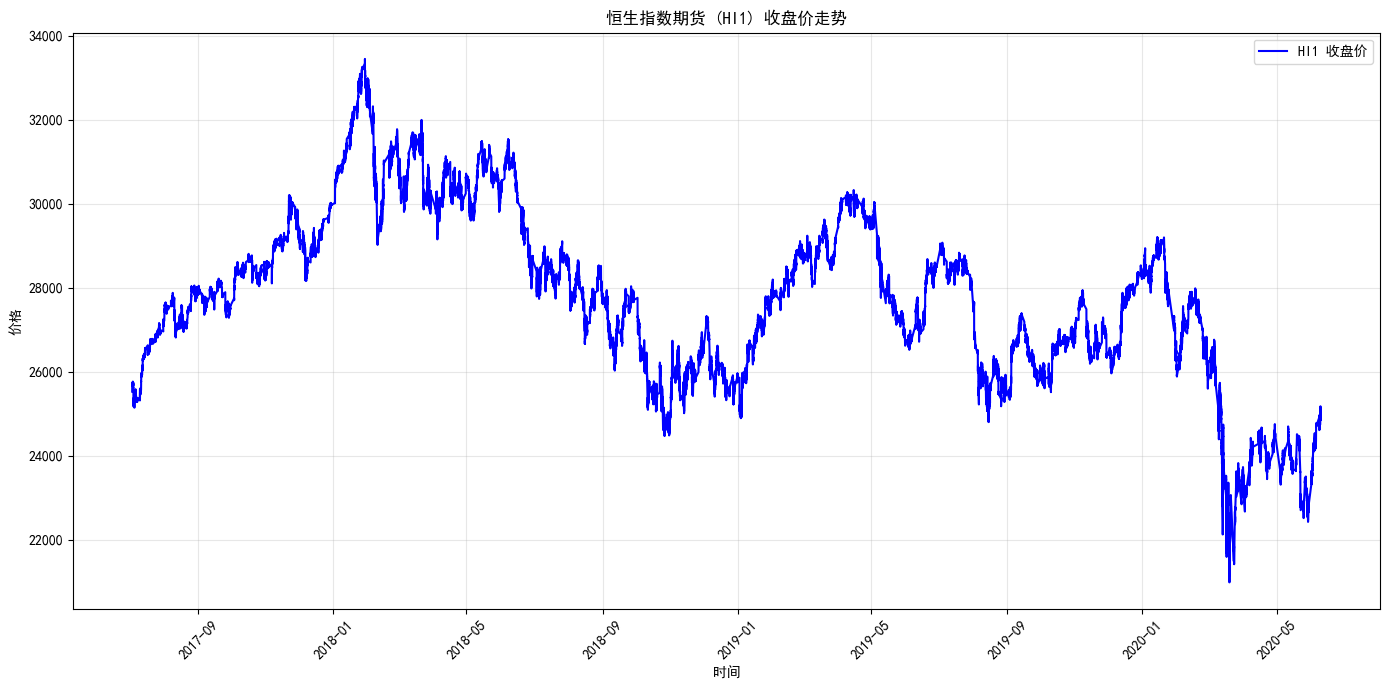

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



file_path = 'D:\code\8020group\data\hi1_20170701_20200609.csv'

# ===============================================

# 1. 读取数据
df = pd.read_csv(file_path)

print("原始数据形状:", df.shape)
print("\n前5行预览:\n", df.head())

# 2. 检查缺失值
print("\n=== 缺失值统计 ===")
print(df.isnull().sum())

# 3. 处理缺失值（金融时间序列常用方法）
price_cols = ['hi1_open', 'hi1_high', 'hi1_low', 'hi1_close']
vol_col = 'hi1_volume'

# 价格类字段：向前填充（前值填充）
df[price_cols] = df[price_cols].ffill()

# 成交量缺失填充为 0
df[vol_col] = df[vol_col].fillna(0)

# 再次检查是否还有缺失值
print("\n处理后缺失值统计:")
print(df.isnull().sum())

# 4. 创建标准的 datetime 索引（关键步骤）
# date 如 20170703，time 如 91400 → 转为 2017-07-03 09:14:00
df['datetime'] = pd.to_datetime(
    df['date'].astype(str) + df['time'].astype(str).str.zfill(6),
    format='%Y%m%d%H%M%S'
)

# 设置为索引并排序
df = df.set_index('datetime')
df = df.sort_index()

print("\n清洗完成！当前数据时间范围:", df.index.min(), "→", df.index.max())
print("最终数据形状:", df.shape)

# 5. 绘制走势折线图（收盘价 + 成交量）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']  # 支持中文（Windows/Mac/Linux）
plt.rcParams['axes.unicode_minus'] = False

# 图1：单纯收盘价走势
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['hi1_close'], label='HI1 收盘价', color='blue', linewidth=1.5)
plt.title('恒生指数期货 (HI1) 收盘价走势')
plt.xlabel('时间')
plt.ylabel('价格')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 图2：价格 + 成交量 双轴图（更直观）
# fig, ax1 = plt.subplots(figsize=(14, 7))
#
# ax1.plot(df.index, df['hi1_close'], color='blue', label='收盘价')
# ax1.set_xlabel('时间')
# ax1.set_ylabel('价格', color='blue')
# ax1.tick_params(axis='y', labelcolor='blue')
# ax1.grid(True, alpha=0.3)
#
# ax2 = ax1.twinx()
# ax2.bar(df.index, df['hi1_volume'], alpha=0.4, color='gray', width=0.0005, label='成交量')
# ax2.set_ylabel('成交量', color='gray')
# ax2.tick_params(axis='y', labelcolor='gray')
#
# plt.title('恒生指数期货 (HI1) 价格与成交量走势')
# fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


df.to_csv('./data/hi1_cleaned.csv')
